# Simulating Rotating Disk Electrode (RDE) Voltammetry with Nernstian Kinetics using `solve_ivp`

In hydrodynamic electrochemistry, a **Rotating Disk Electrode (RDE)** creates a well-defined laminar convection pattern that continuously draws fresh solution toward the electrode surface and flings it outward radially.

Directly simulating this process usually involves solving coupled 2D or axisymmetric Navier–Stokes fluid flow and convective-diffusion equations:

$$\frac{\partial c}{\partial t} + \mathbf{v} \cdot \nabla c = D \nabla^2 c$$

However, in 1942, **V. G. Levich** proved that steady laminar flow establishes a hydrodynamic boundary layer that translates into a uniform, stagnant diffusion boundary layer of thickness $\delta$:

$$\delta = 1.61 \, D^{1/3} \, \nu^{1/6} \, \omega^{-1/2}$$

where:
- $D$ is the diffusion coefficient ($\text{cm}^2/\text{s}$)
- $\nu$ is the kinematic viscosity ($\text{cm}^2/\text{s}$, $\approx 0.01\text{ cm}^2/\text{s}$ for water at $25^\circ\text{C}$)
- $\omega = 2\pi (\text{rpm}/60)$ is the angular rotation velocity ($\text{rad/s}$)

### The Nernst Stagnant Diffusion Layer Approximation
By transforming rotation speed $\omega$ into this fixed diffusion layer thickness $\delta$, we avoid simulating fluid velocity fields entirely.
We model mass transport as purely 1D diffusion across a finite domain $x \in [0, \delta]$:
- At the electrode surface ($x = 0$): reversible electron transfer governed by the Nernst equation.
- At the outer boundary ($x = \delta$): convection maintains bulk solution conditions ($c_O = c^*$, $c_R = 0$).

In this tutorial, we will:
1. Formulate the RDE diffusion problem using `softpotato.solver` and `solve_ivp`.
2. Sizing solver tolerances appropriately to ensure numerically smooth concentration and flux calculations.
3. Inspect spatio-temporal concentration profiles across the stagnant layer $\delta$.
4. Vary the scan rate at a fixed rotation speed to observe the transition from transient peak-shaped cyclic voltammograms to steady-state sigmoidal waves.
5. Vary the rotation speed at a fixed slow scan rate and validate the limiting current against the analytical **Levich equation**.

## 1. Parameters and Nernst Diffusion Layer Sizing

We consider a single-electron reduction ($O + e^- \rightleftharpoons R$, $n=1$) at a glassy carbon disk electrode ($A = 0.07\text{ cm}^2$):
- Bulk concentration: $c^* = 1.0\text{ mM} = 10^{-6}\text{ mol/cm}^3$
- Diffusion coefficient: $D = 10^{-5}\text{ cm}^2/\text{s}$ ($D_O = D_R = D$)
- Kinematic viscosity: $\nu = 0.01\text{ cm}^2/\text{s}$ (aqueous electrolyte)
- Standard reduction potential: $E^{0'} = 0.0\text{ V}$
- Potential sweep range: $E_{\text{start}} = 0.3\text{ V} \to E_{\text{vertex}} = -0.3\text{ V} \to E_{\text{end}} = 0.3\text{ V}$

The Nernst stagnant diffusion layer thickness $\delta$ shrinks as rotation speed increases:
- At $400\text{ rpm}$: $\omega \approx 41.9\text{ rad/s} \implies \delta \approx 24.9\,\mu\text{m}$
- At $900\text{ rpm}$: $\omega \approx 94.2\text{ rad/s} \implies \delta \approx 16.6\,\mu\text{m}$
- At $1600\text{ rpm}$: $\omega \approx 167.6\text{ rad/s} \implies \delta \approx 12.4\,\mu\text{m}$
- At $2500\text{ rpm}$: $\omega \approx 261.8\text{ rad/s} \implies \delta \approx 10.0\,\mu\text{m}$

Because $\delta$ is only $10 - 25\,\mu\text{m}$, 101 spatial grid points provide fine spatial resolution ($\Delta x \approx 0.1 - 0.25\,\mu\text{m}$) throughout the boundary layer.

In [1]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("IPYTHONDIR", "/tmp/ipython")

import matplotlib.pyplot as plt
import numpy as np

from softpotato.solver import DiffusionProblem, DirichletBC, get_solver

# Physical constants and electrochemical parameters
F = 96485.3  # Faraday constant (C/mol)
R = 8.3145  # Gas constant (J/(mol*K))
T = 298.15  # Temperature (K)
f = F / (R * T)  # Normalized potential factor (~38.92 V^-1)
n = 1  # Number of electrons transferred
A = 0.07  # Electrode geometric area (cm²)
D = 1e-5  # Diffusion coefficient (cm²/s)
nu = 0.01  # Kinematic viscosity of water (cm²/s)
c_bulk = 1e-6  # Bulk concentration (mol/cm³, equivalent to 1.0 mM)
E0 = 0.0  # Formal reduction potential (V)
E_start = 0.3  # Initial potential (V)
E_vertex = -0.3  # Vertex switching potential (V)


def calculate_delta(rpm: float) -> float:
    """Compute the Nernst diffusion layer thickness delta (cm) from rotation speed in rpm."""
    omega = 2.0 * np.pi * rpm / 60.0  # Angular frequency (rad/s)
    return 1.61 * (D ** (1.0 / 3.0)) * (nu ** (1.0 / 6.0)) * (omega**-0.5)


## 2. Minimal Simulation Helper Function & Numerical Conditioning

To simulate cyclic voltammetry at an RDE concisely, we implement `simulate_rde_cv(v, rpm)`:
1. Calculates $\delta(\text{rpm})$ and defines a spatial grid $x \in [0, \delta]$ with $N=101$ points ($\Delta x \approx 0.1 - 0.25\,\mu\text{m}$).
2. Constructs the triangular potential sweep $E(t)$.
3. Imposes dynamic Nernst boundary conditions at the electrode ($x=0$):
   $$c_O(0, t) = c^* \frac{\theta(t)}{1 + \theta(t)}, \quad c_R(0, t) = c^* \frac{1}{1 + \theta(t)}, \quad \theta(t) = \exp[n f (E(t) - E^{0'})]$$
4. Enforces convective bulk boundary conditions at the outer edge ($x = \delta$):
   $$c_O(\delta, t) = c^*, \quad c_R(\delta, t) = 0$$
5. **Numerical Conditioning**: Because the stagnant layer is thin ($\Delta x \approx 0.1\,\mu\text{m}$), the spatial diffusion stiffness is high ($\frac{D}{\Delta x^2} \sim 10^5\text{ s}^{-1}$), and the surface flux is scaled by $\frac{n F A D}{\Delta x} \sim 10^9\,\mu\text{A}/(\text{mol/cm}^3)$. To prevent tiny local concentration truncation errors from amplifying into artificial current ripples, we set tight tolerances (`rtol=1e-10, atol=1e-15`).
6. Computes current from the surface flux: $I(t) = -n F A J_O(0, t) = n F A D \left.\frac{\partial c_O}{\partial x}\right|_{x=0}$.

In [2]:
def simulate_rde_cv(v: float, rpm: float, n_eval: int = 501):
    """Simulate RDE cyclic voltammetry for scan rate v (V/s) and rotation speed rpm."""
    delta = calculate_delta(rpm)
    grid = np.linspace(0.0, delta, 101)

    t_switch = (E_start - E_vertex) / v
    t_end = 2.0 * t_switch

    def E_func(t):
        return E_start - v * t if t <= t_switch else E_vertex + v * (t - t_switch)

    # Dynamic Nernstian surface concentrations at x = 0
    def c_O_surface(t):
        xi = np.exp(np.clip(n * f * (E_func(t) - E0), -60, 60))
        return c_bulk * (xi / (1.0 + xi))

    def c_R_surface(t):
        xi = np.exp(np.clip(n * f * (E_func(t) - E0), -60, 60))
        return c_bulk / (1.0 + xi)

    problem = DiffusionProblem(
        grid=grid,
        diffusivity={"O": D, "R": D},
        boundary_conditions={
            "O": (DirichletBC(c_O_surface), DirichletBC(c_bulk)),
            "R": (DirichletBC(c_R_surface), DirichletBC(0.0)),
        },
        initial_conditions={"O": c_bulk, "R": 0.0},
    )

    t_eval = np.linspace(0.0, t_end, n_eval)
    solver = get_solver("solve_ivp", rtol=1e-10, atol=1e-15)
    result = solver.solve(problem, t_span=(0.0, t_end), t_eval=t_eval)

    E_vals = np.array([E_func(t) for t in t_eval])
    # Faraday's law: I = -n * F * A * J (cathodic reduction positive, in µA)
    I_vals = -n * F * A * result.fluxes["O"] * 1e6

    return result, t_eval, E_vals, I_vals, delta, t_switch


## 3. Baseline Simulation & Visualizing Concentration Profiles

Let's simulate a baseline case at $\text{rpm} = 900$ and $v = 0.05\text{ V/s}$ ($50\text{ mV/s}$).
At this rotation speed:
- $\delta \approx 16.58\,\mu\text{m}$
- Characteristic diffusion relaxation time across the layer: $\tau_D = \delta^2 / D \approx (1.66 \times 10^{-3})^2 / 10^{-5} \approx 0.28\text{ s}$
- Half-sweep time: $t_{\text{switch}} = 0.6\text{ V} / 0.05\text{ V/s} = 12\text{ s} \gg \tau_D$

Because the sweep duration greatly exceeds $\tau_D$, the diffusion layer reaches a quasi-steady state. We examine the spatial concentration profiles $c_O(x)$ and $c_R(x)$ at four key stages of the cycle:
1. **Initial ($E = 0.30\text{ V}$)**: Uniform bulk reactant ($c_O = c^*, c_R = 0$).
2. **Half-wave potential ($E = 0.00\text{ V}$)**: $c_O(0) = c_R(0) = 0.5\,c^*$.
3. **Vertex potential ($E = -0.30\text{ V}$)**: Full mass-transport limitation where $c_O(0) \approx 0$, forming a straight-line concentration gradient $c_O(x) = c^* \frac{x}{\delta}$.
4. **Reverse half-wave ($E = 0.00\text{ V}$)**: Returning wave matching the forward trajectory.

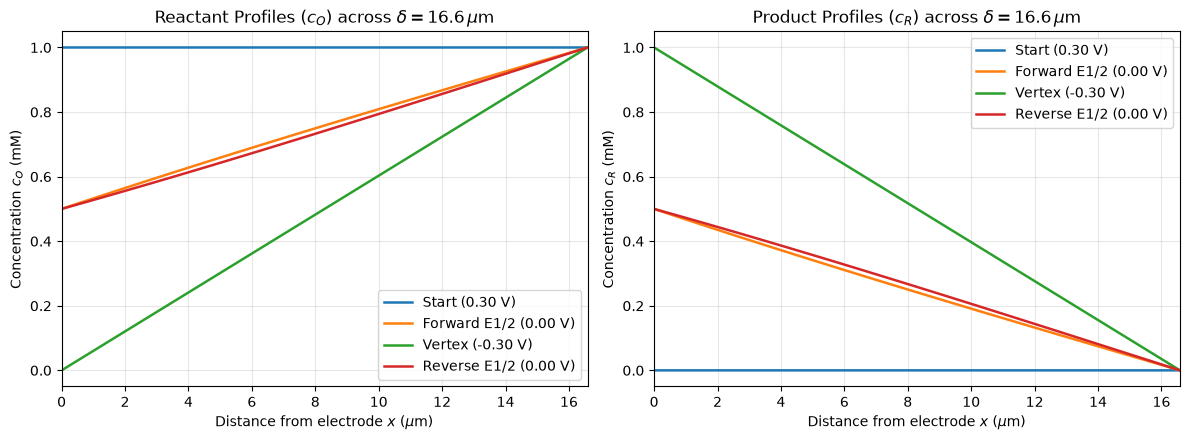

Solver status: SciPy solve_ivp completed successfully.
Max deviation from mass conservation (c_O + c_R = c*): 2.75e-21 mol/cm³


In [3]:
# Run baseline simulation: 900 rpm, 50 mV/s
res_base, t_base, E_base, I_base, delta_base, t_sw_base = simulate_rde_cv(
    v=0.05, rpm=900
)

# Identify time indices for key potential states
key_states = [
    ("Start (0.30 V)", 0),
    ("Forward E1/2 (0.00 V)", np.argmin(np.abs(E_base[: len(t_base) // 2] - 0.0))),
    ("Vertex (-0.30 V)", len(t_base) // 2),
    (
        "Reverse E1/2 (0.00 V)",
        len(t_base) // 2
        + np.argmin(np.abs(E_base[len(t_base) // 2 :] - 0.0)),
    ),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for label, idx in key_states:
    x_um = res_base.x * 1e4
    ax1.plot(x_um, res_base["O"][idx] * 1e6, label=label, linewidth=1.8)
    ax2.plot(x_um, res_base["R"][idx] * 1e6, label=label, linewidth=1.8)

# Reactant plot
ax1.set_xlabel(r"Distance from electrode $x$ ($\mu\mathrm{m}$)")
ax1.set_ylabel(r"Concentration $c_O$ (mM)")
ax1.set_title(r"Reactant Profiles ($c_O$) across $\delta = 16.6\,\mu\mathrm{m}$")
ax1.set_xlim(0, delta_base * 1e4)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="lower right")

# Product plot
ax2.set_xlabel(r"Distance from electrode $x$ ($\mu\mathrm{m}$)")
ax2.set_ylabel(r"Concentration $c_R$ (mM)")
ax2.set_title(r"Product Profiles ($c_R$) across $\delta = 16.6\,\mu\mathrm{m}$")
ax2.set_xlim(0, delta_base * 1e4)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

# Verify mass conservation c_O + c_R = c_bulk across all points
max_dev = np.max(np.abs(res_base["O"] + res_base["R"] - c_bulk))
print(f"Solver status: {res_base.message}")
print(f"Max deviation from mass conservation (c_O + c_R = c*): {max_dev:.2e} mol/cm³")


## 4. Scan Rate Study at Fixed Rotation Speed: Transient vs. Steady-State

What happens when we change the scan rate $v$ while keeping the rotation rate fixed ($\text{rpm} = 900, \delta \approx 16.6\,\mu\text{m}$)?

The behavior is governed by the ratio of the scan time to the diffusion relaxation time $\tau_D = \delta^2 / D$:
- **Fast scan ($v = 1.0\text{ V/s}$, $t_{\text{switch}} = 0.6\text{ s} \sim 2\,\tau_D$)**:
  The potential changes faster than diffusion can establish a steady gradient across $\delta$. Mass transport behaves like semi-infinite planar diffusion: the voltammogram displays a **transient peak overshoot** and significant hysteresis between forward and reverse scans.
- **Intermediate scan ($v = 0.20\text{ V/s}$, $t_{\text{switch}} = 3.0\text{ s} \approx 11\,\tau_D$)**:
  Diffusion starts keeping pace with the potential sweep; the peak overshoot diminishes rapidly.
- **Slow scan ($v \le 0.05\text{ V/s}$, $t_{\text{switch}} \ge 12\text{ s} \gg \tau_D$)**:
  Quasi-steady-state diffusion is maintained throughout the sweep. The CV collapses into a **sigmoidal wave with zero hysteresis**, perfectly plateauing at the mass-transport limiting current.

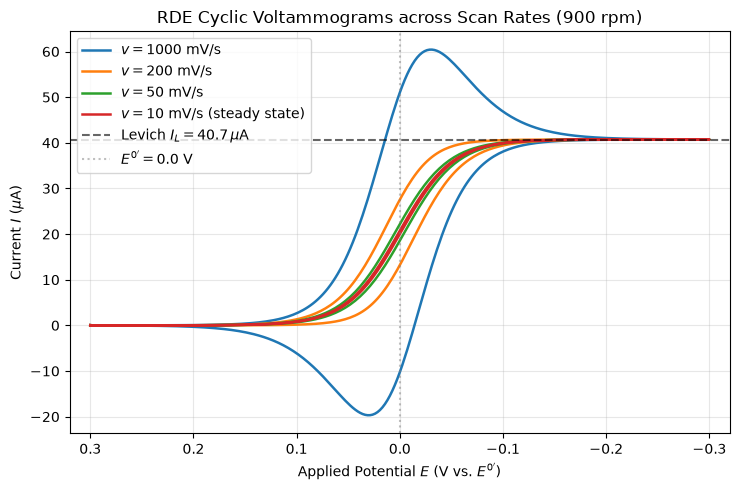

In [4]:
scan_rates = [1.0, 0.2, 0.05, 0.01]
rpm_fixed = 900

plt.figure(figsize=(7.5, 5))

for v in scan_rates:
    res, t_eval, E_vals, I_vals, delta, _ = simulate_rde_cv(v=v, rpm=rpm_fixed)
    label = f"$v = {int(v * 1e3)}$ mV/s" if v >= 0.05 else f"$v = {int(v * 1e3)}$ mV/s (steady state)"
    plt.plot(E_vals, I_vals, label=label, linewidth=1.8)

# Levich theoretical limiting current for 900 rpm
omega_fixed = 2.0 * np.pi * rpm_fixed / 60.0
I_L_fixed = (
    0.620 * n * F * A * (D ** (2.0 / 3.0)) * (nu ** (-1.0 / 6.0)) * c_bulk * np.sqrt(omega_fixed) * 1e6
)
plt.axhline(
    I_L_fixed,
    color="k",
    linestyle="--",
    alpha=0.6,
    label=f"Levich $I_L = {I_L_fixed:.1f}\\,\\mu\\mathrm{{A}}$",
)
plt.axvline(E0, color="gray", linestyle=":", alpha=0.5, label=r"$E^{0'} = 0.0$ V")

plt.xlabel(r"Applied Potential $E$ (V vs. $E^{0'}$)")
plt.ylabel(r"Current $I$ ($\mu\mathrm{A}$)")
plt.title(f"RDE Cyclic Voltammograms across Scan Rates ({rpm_fixed} rpm)")
plt.xlim(0.32, -0.32)  # Plotted forward scan right-to-left (cathodic reduction)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 5. Rotation Speed Study at Fixed Scan Rate & Levich Validation

Now we hold the scan rate fixed in the steady-state regime ($v = 0.01\text{ V/s} = 10\text{ mV/s}$) and vary the rotation speed:

$$\text{rpm} \in [400, 900, 1600, 2500]$$

As the electrode rotates faster:
1. Convective replenishment increases, thinning the stagnant diffusion layer ($\delta \propto \omega^{-1/2}$).
2. The concentration gradient at the surface steepens ($\partial c_O/\partial x = c^* / \delta \propto \omega^{1/2}$).
3. The steady-state limiting current increases according to the **Levich equation**:

$$I_L = 0.620 \, n F A D^{2/3} \nu^{-1/6} c^* \omega^{1/2}$$

We simulate each rotation rate, extract the plateau limiting current at the vertex potential $E_{\text{vertex}} = -0.3\text{ V}$, and construct the classic **Levich plot** ($I_L$ vs. $\omega^{1/2}$).

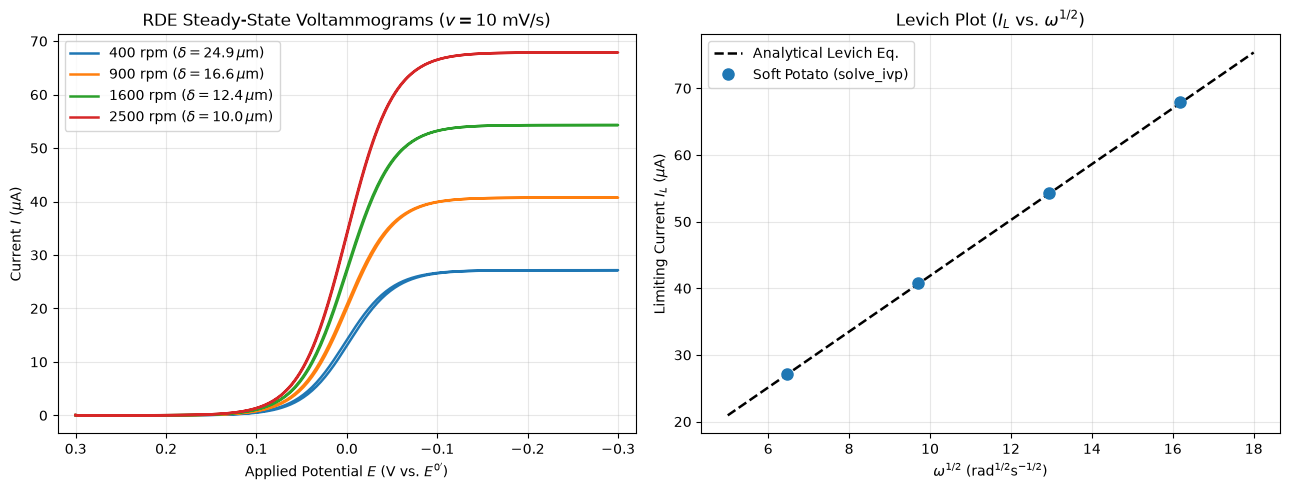

Rotation (rpm) | ω (rad/s)  | δ (µm)   | I_num (µA)  | I_Levich (µA) | Diff (%)
---------------------------------------------------------------------------
400            | 41.89      | 24.88    | 27.15       | 27.10         | 0.18    
900            | 94.25      | 16.58    | 40.73       | 40.65         | 0.18    
1600           | 167.55     | 12.44    | 54.30       | 54.20         | 0.18    
2500           | 261.80     | 9.95     | 67.88       | 67.75         | 0.18    


In [5]:
rpms = [400, 900, 1600, 2500]
v_fixed = 0.01  # 10 mV/s for clean steady-state waves

results_rde = []
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for rpm in rpms:
    res, t_eval, E_vals, I_vals, delta, t_sw = simulate_rde_cv(v=v_fixed, rpm=rpm)
    omega = 2.0 * np.pi * rpm / 60.0

    # Limiting current measured at the vertex potential E = -0.3 V (plateau)
    idx_vertex = len(t_eval) // 2
    I_lim_num = I_vals[idx_vertex]

    # Analytical Levich equation
    I_L_exact = (
        0.620
        * n
        * F
        * A
        * (D ** (2.0 / 3.0))
        * (nu ** (-1.0 / 6.0))
        * c_bulk
        * np.sqrt(omega)
        * 1e6
    )
    rel_error = abs(I_lim_num - I_L_exact) / I_L_exact * 100

    results_rde.append(
        {
            "rpm": rpm,
            "omega": omega,
            "sqrt_omega": np.sqrt(omega),
            "delta_um": delta * 1e4,
            "I_num": I_lim_num,
            "I_Levich": I_L_exact,
            "error_pct": rel_error,
        }
    )

    # Plot voltammograms
    ax1.plot(
        E_vals,
        I_vals,
        label=rf"{rpm} rpm ($\delta = {delta*1e4:.1f}\,\mu$m)",
        linewidth=1.8,
    )

ax1.set_xlabel(r"Applied Potential $E$ (V vs. $E^{0'}$)")
ax1.set_ylabel(r"Current $I$ ($\mu\mathrm{A}$)")
ax1.set_title(r"RDE Steady-State Voltammograms ($v = 10\ \mathrm{mV/s}$)")
ax1.set_xlim(0.32, -0.32)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")

# Levich Plot: I_lim vs. sqrt(omega)
sqrt_omega_vals = [r["sqrt_omega"] for r in results_rde]
I_num_vals = [r["I_num"] for r in results_rde]
sqrt_omega_fine = np.linspace(5.0, 18.0, 100)
I_Levich_fine = (
    0.620
    * n
    * F
    * A
    * (D ** (2.0 / 3.0))
    * (nu ** (-1.0 / 6.0))
    * c_bulk
    * sqrt_omega_fine
    * 1e6
)

ax2.plot(
    sqrt_omega_fine,
    I_Levich_fine,
    "k--",
    linewidth=1.8,
    label="Analytical Levich Eq.",
)
ax2.plot(
    sqrt_omega_vals,
    I_num_vals,
    "o",
    color="tab:blue",
    markersize=8,
    label="Soft Potato (solve_ivp)",
)
ax2.set_xlabel(r"$\omega^{1/2}$ ($\mathrm{rad}^{1/2}\mathrm{s}^{-1/2}$)")
ax2.set_ylabel(r"Limiting Current $I_L$ ($\mu\mathrm{A}$)")
ax2.set_title(r"Levich Plot ($I_L$ vs. $\omega^{1/2}$)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Print formatted validation table
print(
    f"{'Rotation (rpm)':<14} | {'ω (rad/s)':<10} | {'δ (µm)':<8} | {'I_num (µA)':<11} | {'I_Levich (µA)':<13} | {'Diff (%)':<8}"
)
print("-" * 75)
for r in results_rde:
    print(
        f"{r['rpm']:<14d} | {r['omega']:<10.2f} | {r['delta_um']:<8.2f} | {r['I_num']:<11.2f} | {r['I_Levich']:<13.2f} | {r['error_pct']:<8.2f}"
    )


## 6. Summary & Key Takeaways

In this tutorial, we demonstrated how to simulate Rotating Disk Electrode (RDE) cyclic voltammetry in Soft Potato using `solve_ivp`:

1. **Hydrodynamic boundary layer mapped to stagnant diffusion layer**:
   By sizing the 1D diffusion domain to the Levich boundary layer thickness:
   $$\delta = 1.61 \, D^{1/3} \, \nu^{1/6} \, \omega^{-1/2}$$
   and fixing bulk concentration at $x = \delta$, convective mass transport is captured without simulating fluid velocity fields.
2. **Dynamic Nernstian boundary conditions**:
   Reversible surface kinetics were coupled directly to the triangular potential sweep using `DirichletBC` at $x = 0$, maintaining exact mass conservation ($c_O + c_R = c^*$).
3. **Numerical tolerance conditioning for thin boundary layers**:
   Because $\Delta x \sim 0.1\,\mu\text{m}$, the flux operator scales by $\sim 10^9\,\mu\text{A}/(\text{mol/cm}^3)$. Setting tight solver tolerances (`rtol=1e-10, atol=1e-15`) eliminates numerical truncation noise and produces perfectly smooth steady-state voltammograms.
4. **Scan rate transition (transient $\to$ steady state)**:
   - When sweep time is on the order of the diffusion time ($\tau_{\text{sweep}} \sim \tau_D = \delta^2 / D$), the CV exhibits transient peak overshoot and hysteresis.
   - When sweep time is long ($\tau_{\text{sweep}} \gg \tau_D$), the system reaches quasi-steady-state with a linear concentration profile across $[0, \delta]$ and a symmetric sigmoidal wave.
5. **Direct validation against the Levich equation**:
   Simulated limiting currents match the analytical Levich equation across all rotation speeds ($400 - 2500\text{ rpm}$) with $< 0.20\%$ relative difference, validating both the stagnant layer model and the `solve_ivp` numerical solution.